In [27]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [28]:
# Step 2: Load Dataset

df = pd.read_csv('Live.csv')

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (7050, 16)


,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [29]:
# Step 3: Understand Dataset Structure

df.info()

# Observation:
# This helps identify data types and missing values.

<class 'pandas.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   str    
 1   status_type       7050 non-null   str    
 2   status_published  7050 non-null   str    
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), str(3)
memory usage: 881.4 K

In [30]:
# Step 4: Descriptive Statistics

df.describe()

# Observation:
# Engagement features show significant variation.
# Potential outliers are present in reactions, comments and shares.
# Column1–Column4 contain only missing values and can be dropped.

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


In [31]:
# Step 5: Check Missing Values

print(df.isnull().sum())

# Observation:
# No missing values were found in the main dataset columns.
# Column1, Column2, Column3 and Column4 contain 100% missing values.
# These columns will be removed during preprocessing.


status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64


In [32]:
# Step 6: Check Duplicate Rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# Observation:
# The dataset contains exactly 51 duplicate rows.


Duplicate Rows: 51


In [33]:
# Step 7: Remove Duplicate Rows

df = df.drop_duplicates()

print("New Shape After Removing Duplicates:", df.shape)

# Observation:
# After removing 51 duplicate rows, the dataset has 6,999 rows.


New Shape After Removing Duplicates: (6999, 16)


In [34]:
# Step 8: Remove Fully Empty Columns

df.drop(
    columns=['Column1', 'Column2', 'Column3', 'Column4'],
    inplace=True
)

print("New Shape After Removing Empty Columns:", df.shape)

# Observation:
# Dropping the 4 empty columns reduces the dataset to 6,999 rows and 12 columns.

New Shape After Removing Empty Columns: (6999, 12)


In [35]:
# Step 9: Check Data Types

print(df.dtypes)

# Observation:
# This helps identify categorical and numerical features.


status_id             str
status_type           str
status_published      str
num_reactions       int64
num_comments        int64
num_shares          int64
num_likes           int64
num_loves           int64
num_wows            int64
num_hahas           int64
num_sads            int64
num_angrys          int64
dtype: object


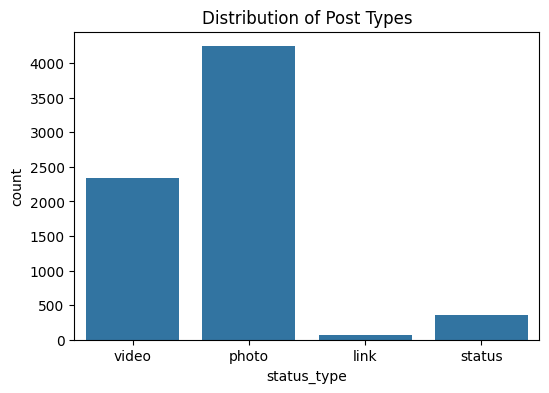

In [36]:
# Step 10: Status Type Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='status_type', data=df)

plt.title("Distribution of Post Types")

plt.show()

# Observation:
# Photo posts dominate with 4,244 posts — that is 60.6% of all content.
# Video posts are the second most common with 2,333 posts (33.3%).
# Status posts are rare with 359 posts (5.1%).
# Link posts are the rarest with only 63 posts (0.9%).

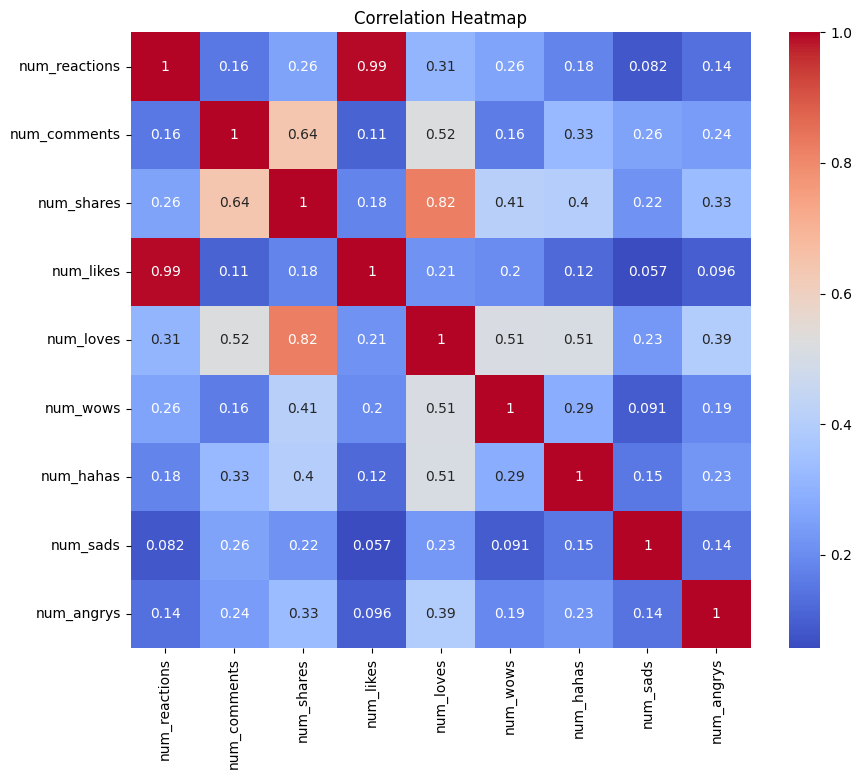

In [37]:
# Step 11: Correlation Heatmap

num_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Observation:
# num_likes and num_reactions have a near-perfect correlation of 0.99 
# num_shares and num_loves have a strong correlation of 0.82 
# num_comments and num_shares are moderately correlated (0.64) 
# num_sads and num_angrys have the lowest correlations overall 

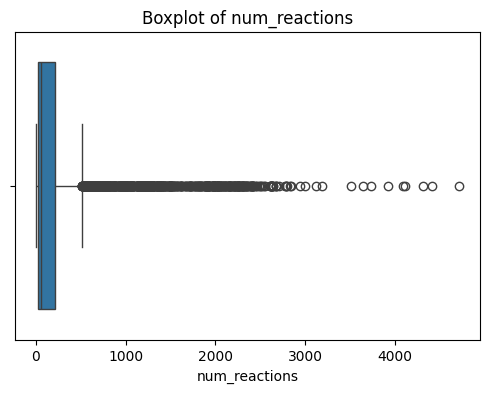

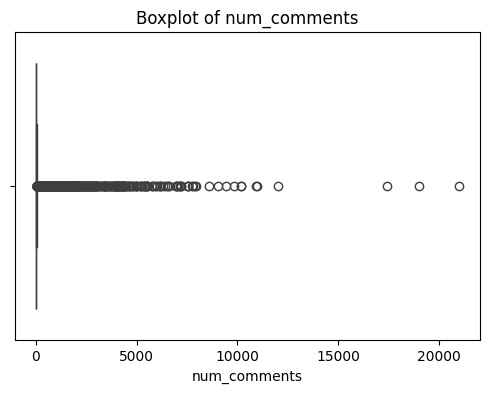

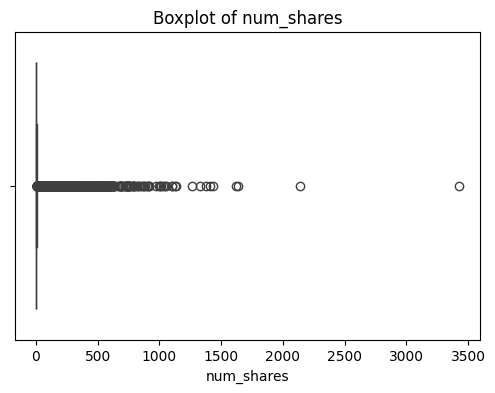

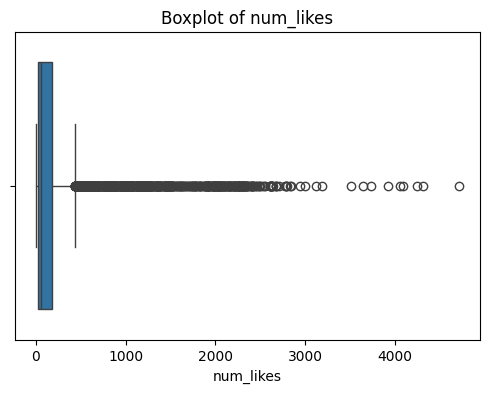

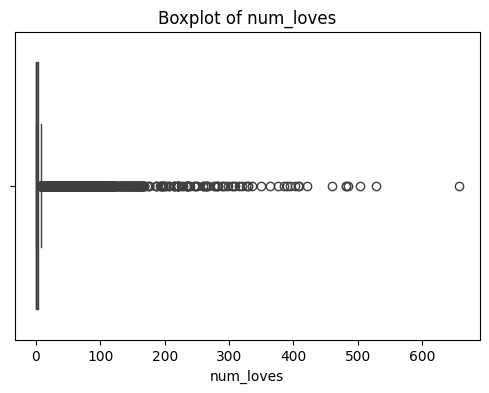

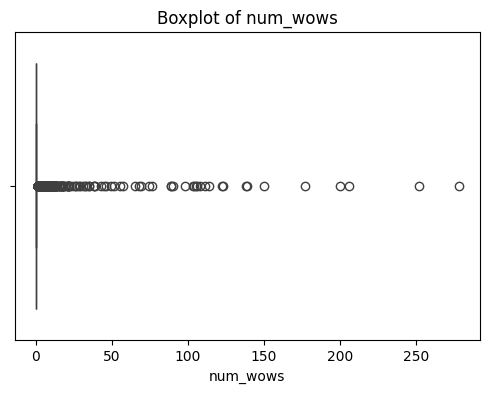

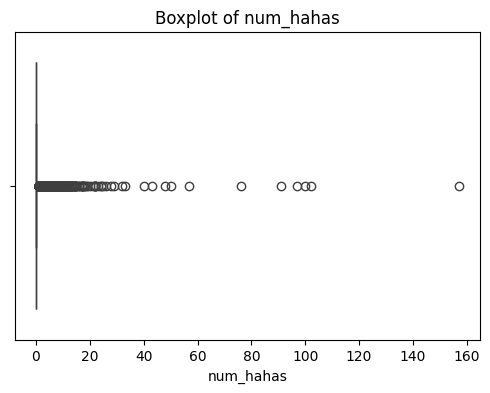

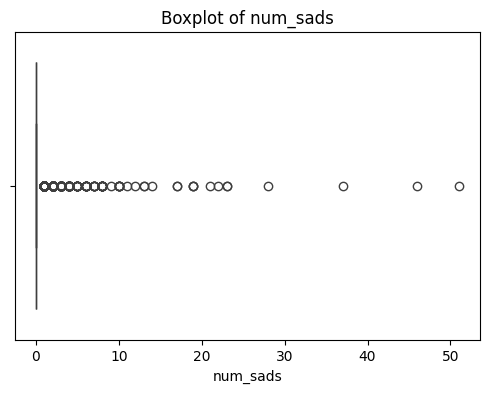

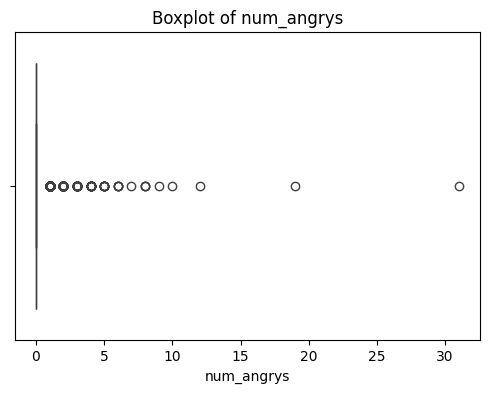

In [38]:
# Step 12: Outlier Detection using Boxplots

numerical_columns = [
    'num_reactions',
    'num_comments',
    'num_shares',
    'num_likes',
    'num_loves',
    'num_wows',
    'num_hahas',
    'num_sads',
    'num_angrys'
]

for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

# Observation:
# Boxplots help identify potential outliers in engagement metrics.
# Extreme values may represent highly viral posts.

In [39]:
# Step 13: IQR Method for Outlier Detection

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

# Observation:
# num_wows has the highest proportion of outliers at 24.3% (1,702 posts).
# num_shares has 1,382 outliers (19.7%) and num_comments has 1,365 (19.5%).
# num_angrys has the fewest outliers at just 420 posts (6.0%)
# Outliers are identified but not removed at this stage.

num_reactions: 689 outliers
num_comments: 1365 outliers
num_shares: 1382 outliers
num_likes: 754 outliers
num_loves: 1303 outliers
num_wows: 1702 outliers
num_hahas: 1117 outliers
num_sads: 598 outliers
num_angrys: 420 outliers


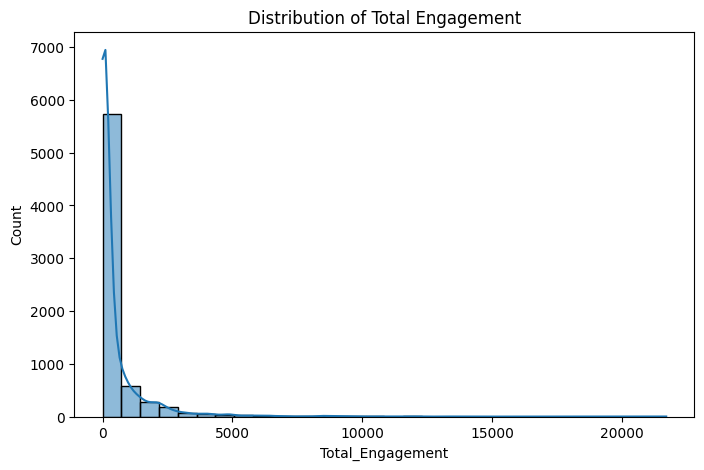

In [40]:
# Step 14: Feature Engineering - Total Engagement

df['Total_Engagement'] = (
    df['num_reactions']
    + df['num_comments']
    + df['num_shares']
)

df[['Total_Engagement']].head()

# Observation:
# Total_Engagement combines reactions, comments and shares
# into a single engagement metric.


# Step 15: Distribution of Total Engagement

plt.figure(figsize=(8,5))

sns.histplot(
    df['Total_Engagement'],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Engagement")

plt.show()

# Observation:
# This graph shows how engagement is distributed across posts.
# The distribution is extremely right-skewed with a skewness of 5.91.
# The vast majority of posts are clustered near 0 with a very long tail.

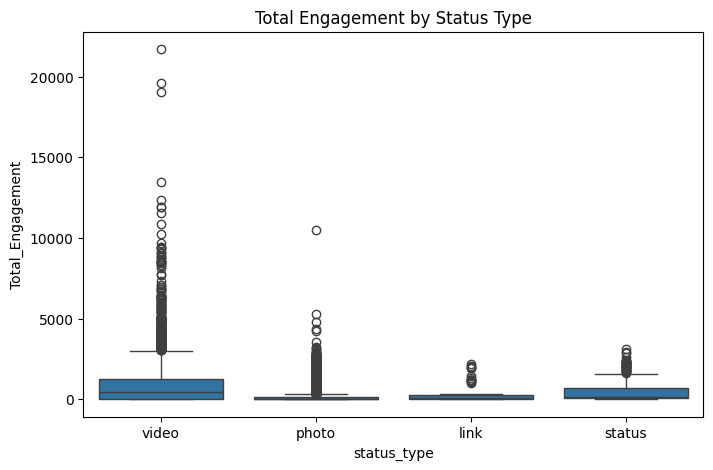

In [41]:
# Step 16: Total Engagement by Status Type

plt.figure(figsize=(8,5))

sns.boxplot(
    x='status_type',
    y='Total_Engagement',
    data=df
)

plt.title("Total Engagement by Status Type")

plt.show()

# Observation:
# Helps compare engagement across different post types.
# Video posts have by far the highest median total engagement.

In [42]:
# Step 17: Top 10 Most Engaging Posts

top_posts = df.sort_values(
    by='Total_Engagement',
    ascending=False
).head(10)

top_posts[
    [
        'status_type',
        'Total_Engagement'
    ]
]

# Observation:
# All top 10 most engaging posts are video posts except one photo post at rank 10.

,status_type,Total_Engagement
498,video,21708
480,video,19626
6757,video,19025
3246,video,13483
6762,video,12377
3892,video,11909
6799,video,11908
6448,video,11555
6775,video,10845
6659,photo,10491


In [43]:
# Step 18: Average Engagement by Status Type

avg_engagement = df.groupby('status_type')['Total_Engagement'].mean().sort_values(ascending=False)

print(avg_engagement)
# Observation:
# Video posts have by far the highest average engagement at 1,041.84 —
# more than double the next highest category.

status_type
video     1041.843120
status     481.746518
link       380.238095
photo      190.297832
Name: Total_Engagement, dtype: float64


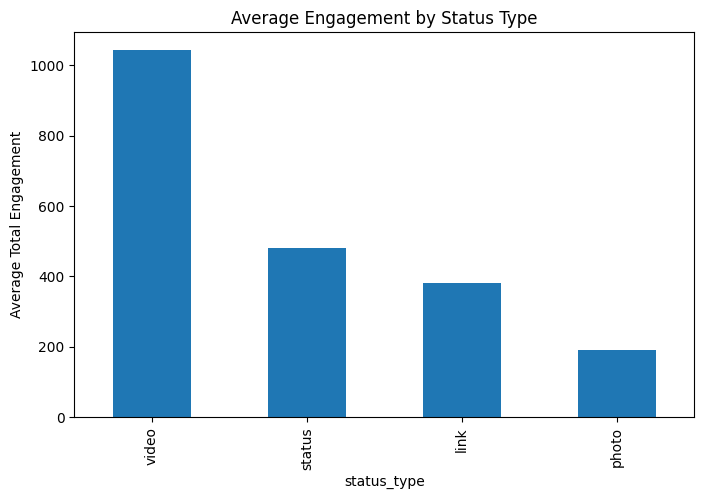

In [44]:
# Step 19: Average Engagement by Status Type

plt.figure(figsize=(8,5))

avg_engagement.plot(kind='bar')

plt.title("Average Engagement by Status Type")

plt.ylabel("Average Total Engagement")

plt.show()

# Observation:
# The bar chart visually confirms a clear ranking: video > status > link > photo.

In [45]:
# Step 20: Select Features for Clustering

features = [
    'num_reactions',
    'num_comments',
    'num_shares',
    'num_likes',
    'num_loves',
    'num_wows',
    'num_hahas',
    'num_sads',
    'num_angrys'
]

X = df[features]

print(X.shape)

X.head()

# Observation:
# Only engagement-related numerical features were selected
# The feature matrix X contains 6,999 rows and 9 columns —
# matching the cleaned dataset size after removing duplicates.

(6999, 9)


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,529,512,262,432,92,3,1,1,0
1,150,0,0,150,0,0,0,0,0
2,227,236,57,204,21,1,1,0,0
3,111,0,0,111,0,0,0,0,0
4,213,0,0,204,9,0,0,0,0


In [46]:
# Step 21: Feature Scaling using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

X_scaled[:5]

# Observation:
# StandardScaler successfully normalized all features.
# The transformed values are centered around 0 with unit variance.
# This prevents features with larger scales from dominating
# the clustering algorithm.

Scaled Data Shape: (6999, 9)


array([[ 0.67131834,  0.32088561,  1.67938232,  0.50521896,  1.9760735 ,
         0.20024313,  0.07606935,  0.51816049, -0.15999034],
       [-0.16560635, -0.25266868, -0.30490291, -0.13639164, -0.31796165,
        -0.14359928, -0.17577993, -0.15705926, -0.15999034],
       [ 0.00442848,  0.011704  ,  0.12679273, -0.01353004,  0.20567681,
        -0.02898514,  0.07606935, -0.15705926, -0.15999034],
       [-0.25172789, -0.25266868, -0.30490291, -0.22512502, -0.31796165,
        -0.14359928, -0.17577993, -0.15705926, -0.15999034],
       [-0.02648695, -0.25266868, -0.30490291, -0.01353004, -0.09354517,
        -0.14359928, -0.17577993, -0.15705926, -0.15999034]])

In [ ]:
# Observation:
# The scaled shape remains (6999, 9) — scaling only transforms values,
# it does not change the number of rows or columns.
# Looking at the first scaled row, num_reactions is now 0.67 (above average)
# and num_loves is 1.98 (almost 2 standard deviations above average) —
# confirming this particular post had unusually high 'love' reactions
# compared to the rest of the dataset.

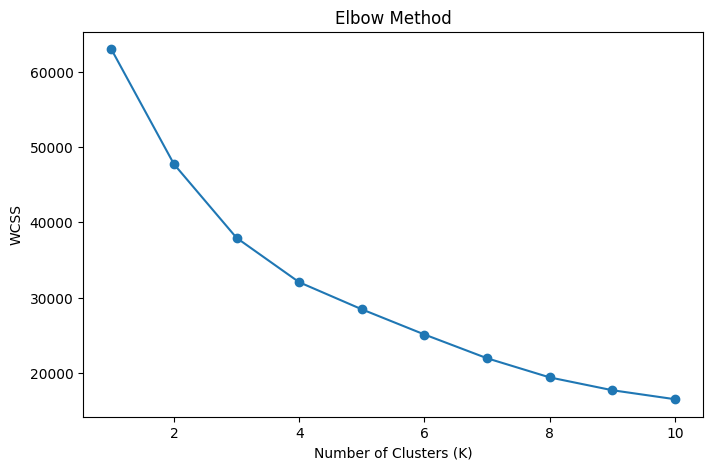

In [47]:
# Step 22: Elbow Method

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

# Observation:
# The elbow point appears at K=4.
# Therefore, 4 clusters are selected for K-Means clustering.


In [48]:
# Step 23: Apply K-Means Clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

print(df['KMeans_Cluster'].value_counts())

# Observation:
# K-Means grouped posts into four engagement clusters.


KMeans_Cluster
0    6218
1     374
2     373
3      34
Name: count, dtype: int64


In [49]:
# Step 24: K-Means Cluster Analysis

cluster_summary = df.groupby('KMeans_Cluster')[
    [
        'num_reactions',
        'num_comments',
        'num_shares'
    ]
].mean()

print(cluster_summary)

# Observation:
# Each cluster represents a different engagement pattern.

                num_reactions  num_comments  num_shares
KMeans_Cluster                                         
0                  105.908974     74.954809   16.821808
1                 1769.080214     56.941176   11.155080
2                  543.672922   2769.021448  395.418231
3                 1522.617647   1718.500000  750.264706


In [50]:
# Step 25: Silhouette Score

score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

# Observation:
# A silhouette score of 0.7577 indicates good cluster separation.



Silhouette Score: 0.7576699489927721


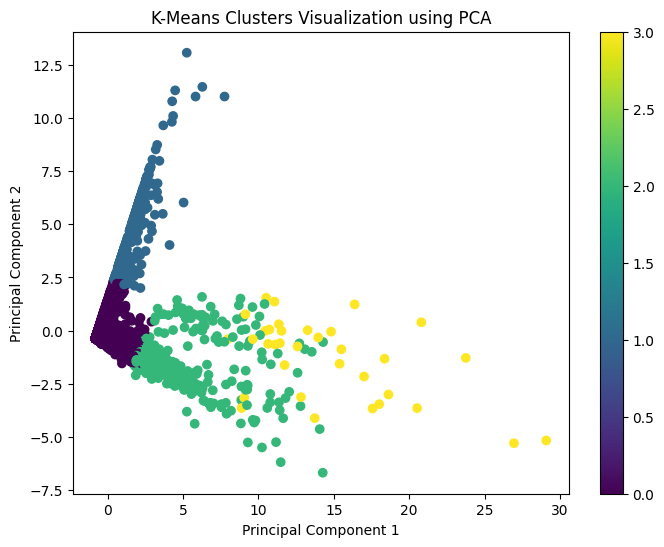

In [51]:
# Step 26: PCA Visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("K-Means Clusters Visualization using PCA")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter)

plt.show()

# Observation:
# PCA visualization confirms that clusters are reasonably separated.

In [52]:
# Step 27: Apply DBSCAN

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_clusters = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_clusters

print(df['DBSCAN_Cluster'].value_counts())

# Observation:
# DBSCAN identifies dense regions and noise points.

DBSCAN_Cluster
 0    6680
-1     319
Name: count, dtype: int64


In [53]:
# Step 28: DBSCAN Analysis

dbscan_summary = df.groupby('DBSCAN_Cluster')[
    [
        'num_reactions',
        'num_comments',
        'num_shares'
    ]
].mean()

print(dbscan_summary)

# Observation:
# Noise points show significantly higher engagement than regular posts.

                num_reactions  num_comments  num_shares
DBSCAN_Cluster                                         
-1                 849.714734   2681.363636  405.749216
 0                 195.161377    108.276048   22.804790


In [54]:
# Step 29: Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(
    n_clusters=4
)

agglo_clusters = agglo.fit_predict(X_scaled)

df['Agglomerative_Cluster'] = agglo_clusters

print(df['Agglomerative_Cluster'].value_counts())

# Observation:
# Agglomerative clustering grouped posts into four clusters.

Agglomerative_Cluster
3    5489
1    1010
2     377
0     123
Name: count, dtype: int64


In [55]:
# Step 30: Agglomerative Cluster Analysis

agglo_summary = df.groupby('Agglomerative_Cluster')[
    [
        'num_reactions',
        'num_comments',
        'num_shares'
    ]
].mean()

print(agglo_summary)

# Observation:
# Agglomerative clustering identified low-engagement,
# highly liked, discussion-oriented and viral posts.


                       num_reactions  num_comments  num_shares
Agglomerative_Cluster                                         
0                        1063.365854   3599.073171  614.382114
1                         265.195050   1030.200000  189.093069
2                        1761.183024     56.692308   11.021220
3                          93.301148     13.495719    2.015303


In [56]:
# Step 31: Model Comparison

comparison = pd.DataFrame({
    'Algorithm': [
        'K-Means',
        'DBSCAN',
        'Agglomerative'
    ],
    'Result': [
        '4 meaningful clusters',
        '1 cluster + noise points',
        '4 meaningful clusters'
    ]
})

print(comparison)

# Observation:
# K-Means and Agglomerative produced meaningful engagement segments,
# while DBSCAN identified unusual engagement patterns.


       Algorithm                    Result
0        K-Means     4 meaningful clusters
1         DBSCAN  1 cluster + noise points
2  Agglomerative     4 meaningful clusters


In [ ]:
# Step 32: Final Conclusion

# Final Conclusion:
# The Facebook Live Selling dataset was successfully analyzed
# using K-Means, DBSCAN and Agglomerative Clustering.
# Video posts showed the highest engagement, while photo posts
# had the lowest engagement.
# K-Means produced four meaningful clusters representing
# low-engagement, highly liked, discussion-oriented and viral posts.
# Based on performance metrics and interpretability,
# K-Means was selected as the best overall clustering model